# **Assignment 13**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from IPython.display import HTML
import joblib
import random
import torch.nn.functional as F
from sklearn.metrics import f1_score
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from torchinfo import summary
from datetime import datetime
import json
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score
)



if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

random_seed = 42

In [2]:
def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined


def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files


def select_joints(X, joints):
    selected_cols = []
    for col in X.columns:
        if any(joint in col for joint in joints):
            selected_cols.append(col)
    
    return X[selected_cols].copy()

# Function to only use every n'th frame
def select_every_nth_frame(df, step=3):
    selected_cols = []

    for col in df.columns:
        # Extract frame number
        frame_part = col.split("_")[0]
        frame_idx = int(frame_part.replace("frame", ""))

        if frame_idx % step == 0:
            selected_cols.append(col)

    return df[selected_cols].copy()

def angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2

    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    # Handle degenerate cases
    if norm_v1 == 0 or norm_v2 == 0:
        return np.nan

    cos_angle = np.dot(v1, v2) / (norm_v1 * norm_v2)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cos_angle))

def add_angle_features(df, frames=173):
    df = df.copy()

    # Store aggregated features per row (video)
    features = []

    for idx, row in df.iterrows():
        left_knee, right_knee = [], []
        left_hip, right_hip = [], []

        for f in range(frames):
            prefix = f"frame{f}"

            try:
                def get(joint):
                    return np.array([
                        row[f"{prefix}_{joint}_x"],
                        row[f"{prefix}_{joint}_y"],
                        row[f"{prefix}_{joint}_z"]
                    ])

                lk = angle(get("left_hip"), get("left_knee"), get("left_foot"))
                rk = angle(get("right_hip"), get("right_knee"), get("right_foot"))

                lh = angle(get("left_shoulder"), get("left_hip"), get("left_knee"))
                rh = angle(get("right_shoulder"), get("right_hip"), get("right_knee"))

                left_knee.append(lk)
                right_knee.append(rk)
                left_hip.append(lh)
                right_hip.append(rh)

            except:
                continue

        # Aggregate per video
        features.append({
            "lk_mean": np.mean(left_knee),
            "lk_min": np.min(left_knee),
            "lk_max": np.max(left_knee),

            "rk_mean": np.mean(right_knee),
            "rk_min": np.min(right_knee),
            "rk_max": np.max(right_knee),

            "lh_mean": np.mean(left_hip),
            "lh_min": np.min(left_hip),
            "lh_max": np.max(left_hip),

            "rh_mean": np.mean(right_hip),
            "rh_min": np.min(right_hip),
            "rh_max": np.max(right_hip),
        })

    feature_df = pd.DataFrame(features, index=df.index)

    return feature_df

## Load cut and padded squat sequences with target determining if squat good or bad

In [3]:
# padded videos with target 0 or 1 based on if it's a bad or good squat
data_folder = "../data/mediapipe_padded_videos"

# Split which files should be train, val and test - we use 70/30 train/test due to small amount of samples
training_proportion = 0.7
validation_proportion = 0

train_files, test_files = split_csvfiles(data_folder, random_seed, training_proportion, validation_proportion)

# Load df from files selected to be either training or testing
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)


# Split
y_train = train_data["target"]
x_train = train_data.drop(columns="target")
y_test = test_data["target"]
x_test = test_data.drop(columns="target")

# To reduce amount of features we only use the following joints
useful_joints = ["left_shoulder", "right_shoulder", "left_hip", "right_hip", "left_knee", "right_knee",
                 "left_foot", "right_foot"]

x_train = select_joints(x_train, useful_joints)
x_test = select_joints(x_test, useful_joints)

# Reduce amount of features by only using every n'th frame
x_train = select_every_nth_frame(x_train, step=3)
x_test = select_every_nth_frame(x_test, step=3)

# Use feature engineering for angles?
USE_ANGLE_FEATURES = True

# Optional: angle features
if USE_ANGLE_FEATURES:
    angle_train = add_angle_features(x_train)
    angle_test  = add_angle_features(x_test)

    # Only keep NEW angle columns
    new_angle_cols = [col for col in angle_train.columns if col not in x_train.columns]

    # Concatenate
    x_train = pd.concat([x_train, angle_train[new_angle_cols]], axis=1)
    x_test  = pd.concat([x_test,  angle_test[new_angle_cols]], axis=1)

    # Handle NaNs safely
    x_train = x_train.fillna(0)
    x_test  = x_test.fillna(0)

# Check dimensions
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(72, 1404)
(72,)
(31, 1404)
(31,)


## Define functions

In [4]:
# Define dense squat classifying model
class SquatClassifierDense(nn.Module):
    def __init__(self, input_dim, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []
        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        prev_size = input_dim

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activations[activation])

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)

    def forward(self, x):
        return self.network(x)


def build_dense_model(config, input_size):
    return SquatClassifierDense(
        input_dim=input_size,
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)


# Compute metrics
def compute_metrics(y_true, probs, threshold=0.5):

    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)

    # AUC
    auc = roc_auc_score(y_true, probs)

    return {
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }


# Modified Karl's augmentation function for training
def mirror_dataframe(df, mirror_x=True, mirror_y=True, mirror_z=True):
    """
    Mirror pose data by swapping left/right joints.

    Assumes column format: frameX_joint_coord
    """

    df_copy = df.copy()

    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]

    for col in df.columns:
        parts = col.split("_")

        # Example: frame0_left_knee_x
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])

        for left, right in mirror_pairs:

            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

    return df_copy

# Full batch since it's faster on my cpu
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):

    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_auc = 0
    best_state = None

    patience = 10
    epochs_no_improve = 0

    # Convergence tracking
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_auc": []
    }

    for epoch in range(epochs):

        # Training
        model.train()
        optimizer.zero_grad()

        logits = model(x_train)
        train_loss = loss_fn(logits, y_train)

        train_loss.backward()
        optimizer.step()

        # Validation with auc as main metric
        model.eval()
        with torch.no_grad():
            val_logits = model(x_val)

            val_loss = loss_fn(val_logits, y_val)

            probs = torch.sigmoid(val_logits)

            val_auc = roc_auc_score(
            y_val.cpu().numpy().ravel(),
            probs.cpu().numpy().ravel()
            )

        # Store history for each epoch
        history["train_loss"].append(train_loss.item())
        history["val_loss"].append(val_loss.item())
        history["val_auc"].append(val_auc)

        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    # Load best weights
    model.load_state_dict(best_state)

    return best_val_auc, model, history


# Cross validation
def cross_validate_model(config, X, y, loss_fn, input_size, n_splits=10):

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    #kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_auc_scores = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        # Split data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # --Augmentate for each individual fold to avoid leakage--
        # Mirror augmentation
        X_train = pd.concat([X_train, mirror_dataframe(X_train)])
        y_train = np.concatenate([y_train, y_train])

        # Rotation augmentation?



        # --Scale for each fold  to avoid data leakage-- (df -> np.array)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        # Convert the y array to numpy arrays too
        y_train = np.asarray(y_train)
        y_val   = np.asarray(y_val)

        # Convert to tensors
        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        X_val   = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_train = torch.tensor(y_train, dtype=torch.float32).to(device).view(-1, 1)
        y_val = torch.tensor(y_val, dtype=torch.float32).to(device).view(-1, 1)

        # Build fresh model
        model = build_dense_model(config, input_size)

        # Train
        val_auc, model, history = train_one_model(
            model, config,
            X_train, y_train,
            X_val, y_val,
            loss_fn
        )

        fold_auc_scores.append(val_auc)
        fold_histories.append(history)


    # Aggregate results
    mean_auc = np.mean(fold_auc_scores)
    std_auc  = np.std(fold_auc_scores)

    return {
        "cv_mean_auc": mean_auc,
        "auc_std": std_auc,
        "fold_scores": fold_auc_scores
    }

## Functions for model handling

In [5]:
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# Changed to be auc based

def save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    model_path = os.path.join(champion_dir, "champion_model.pt")
    info_path = os.path.join(metadata_dir, "champion_info.json")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save metadata
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "auc": float(auc),
        "recall": float(recall),
        "precision": float(precision),
        "accuracy": float(accuracy),
        "hyperparameters": hyperparameters
    }

    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print("New champion model saved!")


# Auc based
def update_champion(metadata_dir, champion_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    current = load_champion_info(metadata_dir)

    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)

    elif auc > current["auc"]:
        print(f"New model is better (auc {auc} > {current['auc']})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)

    else:
        print(f"Model NOT better (auc {auc} < {current['auc']})")

# Cross validation grid search for tuning the model 

In [6]:
param_grid = {"layers": [[128, 64], [256, 128, 64], [64, 32]],
              "lr": [0.001],
              "dropout": [0, 0.1],
              "activation": ["relu", "leaky_relu"],
              "epochs": [100, 200]
            }

trial = 0
best_auc = 0
best_config = None
loss_func = nn.BCEWithLogitsLoss()


# Make configuration of every existing combinations of grid values
for values in product(
    param_grid["layers"],
    param_grid["lr"],
    param_grid["dropout"],
    param_grid["activation"],
    param_grid["epochs"]
    ):

    config = {
        "layers": values[0],
        "lr": values[1],
        "dropout": values[2],
        "activation": values[3],
        "epochs": values[4]
        }

    print(f"\nTrial: {trial + 1}")
    print(config)

    # Extract the number of features
    input_size = x_train.shape[1]

    # Cross validation
    results = cross_validate_model(config, x_train, y_train, loss_func, input_size)

    auc_score = results["cv_mean_auc"]
    auc_std = results["auc_std"]
    fold_scores = results["fold_scores"]

    print(f"AUC fold scores: {fold_scores}")
    print(f"CV mean AUC: {auc_score} +- {auc_std}")

    # Update best config
    if auc_score > best_auc:
        best_auc = auc_score
        best_config = config
    
    trial += 1


Trial: 1
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0, 'activation': 'relu', 'epochs': 100}
AUC fold scores: [0.9166666666666667, 1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 0.8, 0.5, 1.0]
CV mean AUC: 0.9016666666666666 +- 0.155

Trial: 2
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0, 'activation': 'relu', 'epochs': 200}
AUC fold scores: [0.9166666666666667, 1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 0.7, 1.0, 1.0]
CV mean AUC: 0.9416666666666668 +- 0.10144785195688802

Trial: 3
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0, 'activation': 'leaky_relu', 'epochs': 100}
AUC fold scores: [1.0, 1.0, 0.8333333333333334, 0.9, 1.0, 1.0, 0.9, 0.6000000000000001, 1.0, 1.0]
CV mean AUC: 0.9233333333333335 +- 0.122065556157337

Trial: 4
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0, 'activation': 'leaky_relu', 'epochs': 200}
AUC fold scores: [1.0, 1.0, 1.0, 0.8, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
CV mean AUC: 0.9800000000000001 +- 0.05999999999999999

Trial: 5
{'layers': [128, 64], 'lr': 0.001, 'dropout': 0.1, 'activa

# Get best config, re-build model and train on all train data

In [7]:
# Scale all train and test x data (not fold based like in cv)
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = x_test.columns)

# Make train/val split out of training data for final re-train
x_tr, x_val, y_tr, y_val = train_test_split(x_train_scaled, y_train, test_size=0.2, random_state=42, stratify = y_train)

# -- Data Augmentation --
# Mirroring
x_tr = pd.concat([x_tr, mirror_dataframe(x_tr)])
y_tr = np.concatenate([y_tr, y_tr])

# Tensorize
X_tr = torch.tensor(x_tr.values, dtype=torch.float32).to(device)
Y_tr  = torch.tensor(y_tr, dtype=torch.float32).to(device).view(-1, 1)
X_val = torch.tensor(x_val.values, dtype=torch.float32).to(device)
Y_val = torch.tensor(np.array(y_val), dtype=torch.float32).to(device).view(-1, 1)

# Re-build best model
print(best_config)
input_size = x_train.shape[1]
model = build_dense_model(best_config, input_size)

# Train on all training data
val_auc, best_model, history = train_one_model(model, best_config, X_tr, Y_tr, X_val, Y_val, nn.BCEWithLogitsLoss())

print(f"Training AUC: {val_auc}")

# Summarize model
summary(best_model, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])


{'layers': [64, 32], 'lr': 0.001, 'dropout': 0, 'activation': 'leaky_relu', 'epochs': 100}
Training AUC: 1.0


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SquatClassifierDense                     [1, 1404]                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1404]                 [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 1404]                 [1, 64]                   89,920                    True
│    └─LeakyReLU: 2-2                    [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 32]                   2,080                     True
│    └─LeakyReLU: 2-4                    [1, 32]                   [1, 32]                   --                        --
│    └─Linear: 2-5                       [1, 32]                   [1, 1]                    33                        True
Total p

# Evaluate on test and save model if champion

TEST EVALUATION
Test AUC: 0.9786
Accuracy: 0.9355
Precision: 0.9000
Recall: 1.0000


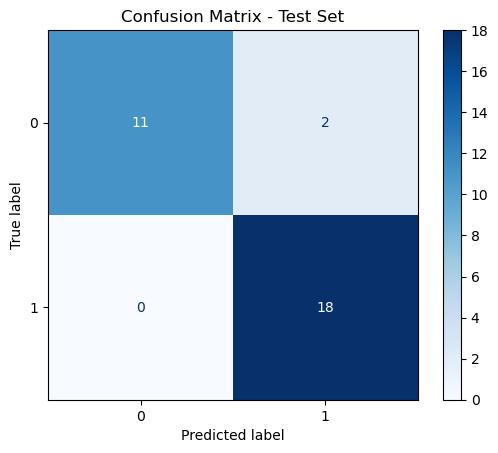

New model is better (auc 0.9786324786324787 > 0.9102564102564101)
New champion model saved!


In [9]:
# Tensorize test data
x_test = torch.tensor(np.array(x_test_scaled), dtype=torch.float32).to(device)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32).to(device)

best_model.eval()
with torch.no_grad():
    logits = best_model(x_test)
    probs = torch.sigmoid(logits)

    y_true = y_test.cpu().numpy().ravel()
    y_scores = probs.cpu().numpy().ravel()

    test_auc = roc_auc_score(y_true, y_scores)

    preds = (probs >= 0.5).cpu().numpy().astype(int).ravel()
    
    accuracy = accuracy_score(y_true, preds)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)

print("TEST EVALUATION")
print(f"Test AUC: {test_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

cm = confusion_matrix(y_true, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()


# -- Save model if it performs better than the current champion --
metadata_dir = "../squat_classifying_models/dense_model/metadata"
champion_dir = "../squat_classifying_models/dense_model/champion_model"

os.makedirs(metadata_dir, exist_ok=True)
os.makedirs(champion_dir, exist_ok=True)

update_champion(
    metadata_dir=metadata_dir,
    champion_dir=champion_dir,
    model=best_model,
    model_name="squat_classifier_dense",
    auc=test_auc,
    recall=recall,
    precision=precision,
    accuracy=accuracy,
    hyperparameters=best_config
)
